In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
imagem = cv2.imread('dataset/watch.png')

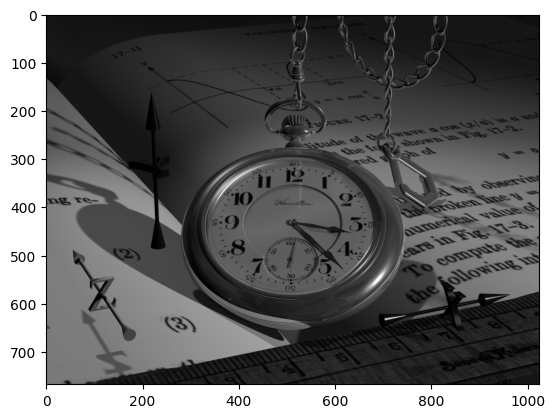

In [4]:
imagem_mono = np.zeros_like(imagem).astype(np.float64)
imagem_mono =  0.2989*imagem[:,:,0] + 0.5870*imagem[:,:,0] + 0.1140*imagem[:,:,0]

plt.imshow(imagem_mono, cmap='gray')

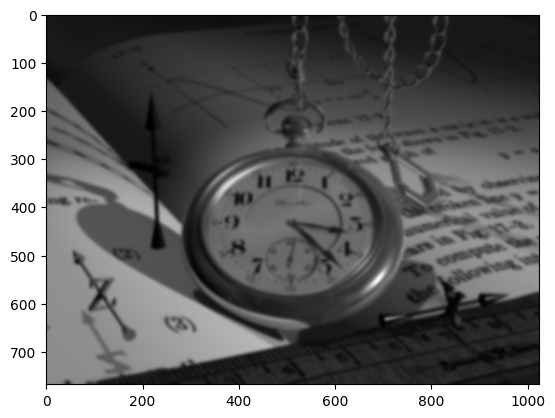

In [ ]:
def mascara_gausiana(size, sigma=1.0):
    centro = size // 2
    x = np.arange(0, size) - centro         
    gauss_1d = np.exp(-x**2 / (2 * sigma**2))
    gauss_1d /= gauss_1d.sum()              
    kernel = np.outer(gauss_1d, gauss_1d)    
    return kernel

K = mascara_gausiana(21, sigma=3.0)

imagem_suavizada = cv2.filter2D(imagem_mono,-1, K)

plt.imshow(imagem_suavizada, cmap="gray")

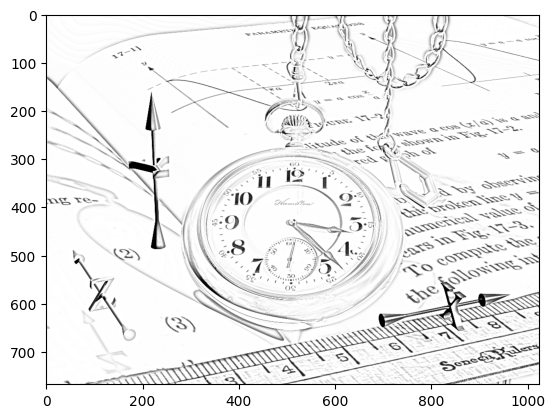

In [14]:

desenho = imagem_mono / imagem_suavizada * 255
desenho = np.clip(desenho, 0, 255).astype(np.uint8)

plt.imshow(desenho, cmap="gray")